<a href="https://colab.research.google.com/github/bjrrnet/argkille/blob/main/TAM400_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
import sys
from packaging import version
import sklearn

assert sys.version_info >= (3, 7) #This line checks that the version of Python being used is 3.7 or higher
assert version.parse(sklearn.__version__) >= version.parse("1.0.1") #This line checks that the version of Scikit-learn being used is 1.0.1 or higher.

In [ ]:
from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations

def load_housing_data():
    # Define the path to the tarball file
    tarball_path = Path("datasets/housing.tgz")

    # Check if the tarball file already exists
    if not tarball_path.is_file():
        # Create the datasets directory if it does not exist
        Path("datasets").mkdir(parents=True, exist_ok=True)

        # URL where the dataset is located
        url = "https://github.com/ageron/data/raw/main/housing.tgz"

        # Download the tarball file from the URL to the specified path
        urllib.request.urlretrieve(url, tarball_path)

        # Open the tarball file
        with tarfile.open(tarball_path) as housing_tarball:
            # Extract all files from the tarball to the datasets directory
            housing_tarball.extractall(path="datasets")


    ##### Here is our main activity ######
    # Load the housing.csv file into a pandas DataFrame and return it
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# Call the function to load the housing data into a DataFrame
housing = load_housing_data()

# Display the first five rows of the housing DataFrame to get an initial overview of the data
housing.head()




,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:

# Display the count of unique values in the "ocean_proximity" column to understand the distribution of this categorical feature
housing["ocean_proximity"].value_counts()



,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
# Generate descriptive statistics for the numerical columns in the housing DataFrame to summarize the central tendency, dispersion, and shape of the dataset's distribution
housing.describe()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


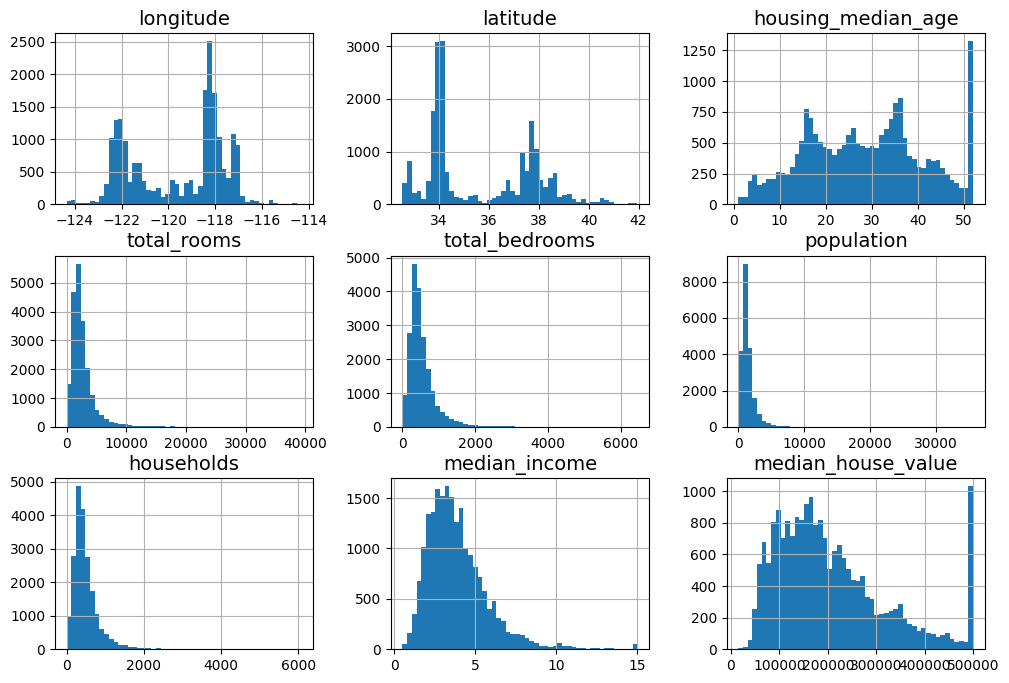

In [ ]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Generate histograms for each numerical column in the housing DataFrame
housing.hist(bins=50, figsize=(12, 8)) # Plot histograms with 50 bins and a figure size of 12x8 inches
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

TASK 2:

In [ ]:
import numpy as np  # Importing the numpy library, which provides support for large, multi-dimensional arrays and matrices

def shuffle_and_split_data(data, test_ratio):
    # Shuffle the indices of the data randomly
    shuffled_indices = np.random.permutation(len(data)) #generates a randomly shuffled array of indices from 0 to the length of the dataset minus one. This ensures that the data is randomly shuffled before splitting.

    # Calculate the size of the test set based on the test_ratio
    test_set_size = int(len(data) * test_ratio)

    # Select the first part of the shuffled indices as the test set indices
    test_indices = shuffled_indices[:test_set_size]

    # Select the remaining part of the shuffled indices as the training set indices
    train_indices = shuffled_indices[test_set_size:]

    # Return the training and test sets based on the indices
    return data.iloc[train_indices], data.iloc[test_indices]

In [ ]:
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = shuffle_and_split_data(housing, 0.2)

# Output the length of the training set to verify the split
len(train_set)

16512

In [ ]:
len(test_set)

4128

In [ ]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

In [ ]:
np.random.seed(42)

In [ ]:
from sklearn.model_selection import train_test_split
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [ ]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

In [ ]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

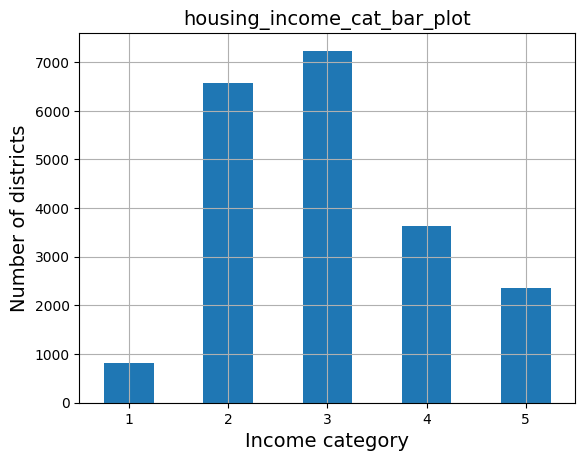

In [ ]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
#save_fig("housing_income_cat_bar_plot")  # extra code
plt.title("housing_income_cat_bar_plot")
plt.show()

In [ ]:

from sklearn.model_selection import StratifiedShuffleSplit  # Importing StratifiedShuffleSplit for creating stratified train-test splits

# Initialize the StratifiedShuffleSplit object with 10 splits, 20% test size, and a random state for reproducibility
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Initialize an empty list to store the stratified splits
strat_splits = []

# Iterate through the splits generated by the StratifiedShuffleSplit object
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    # Create the training set using the train indices
    strat_train_set_n = housing.iloc[train_index]

    # Create the test set using the test indices
    strat_test_set_n = housing.iloc[test_index]

    # Append the training and test sets as a pair to the list of stratified splits
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [ ]:
# Extract the first pair of stratified training and test sets
strat_train_set, strat_test_set = strat_splits[0]

In [ ]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [ ]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


TASK 3:

In [ ]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [ ]:
#creates a copy of the strat_train_set DataFrame
housing = strat_train_set.copy()

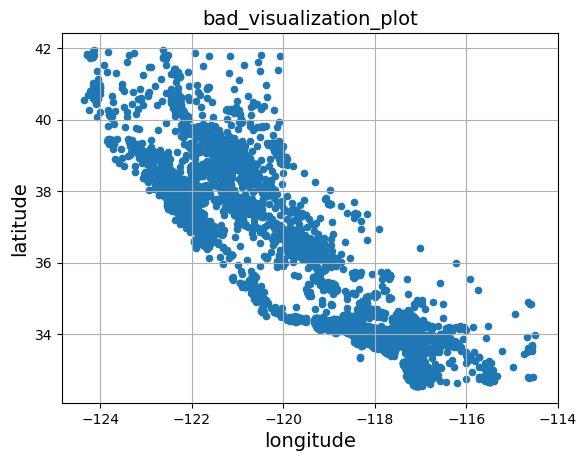

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
#save_fig("bad_visualization_plot")  # extra code
plt.title("bad_visualization_plot")
plt.show()

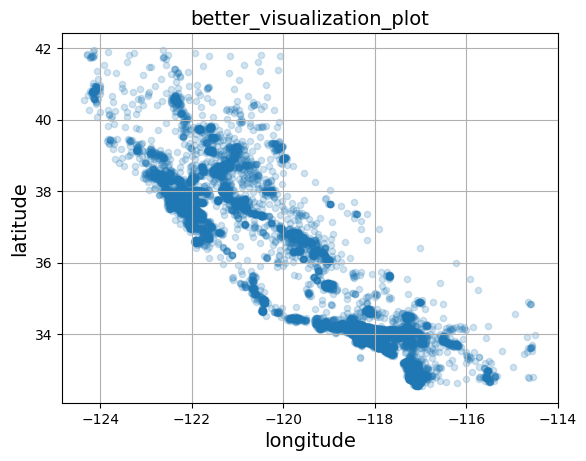

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
#save_fig("better_visualization_plot")  # extra code
plt.title("better_visualization_plot")
plt.show()

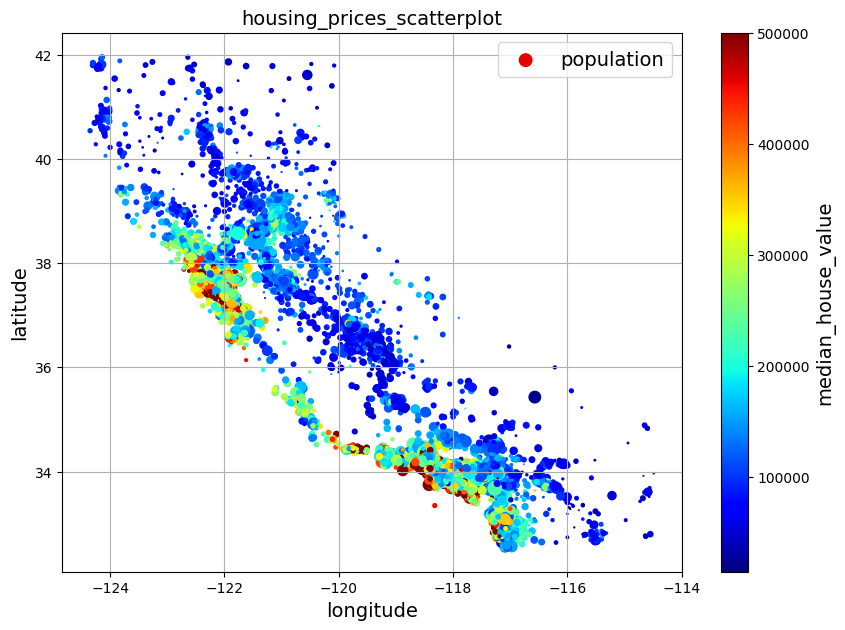

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
#save_fig("housing_prices_scatterplot")  # extra code
plt.title("housing_prices_scatterplot")
plt.show()



In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)


,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


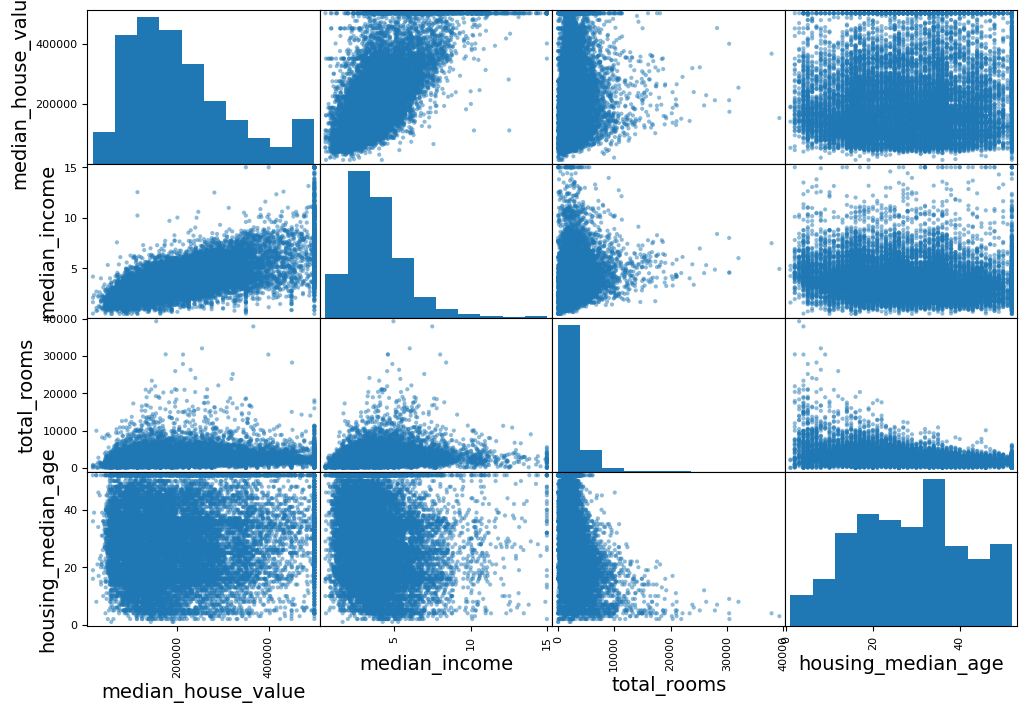

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

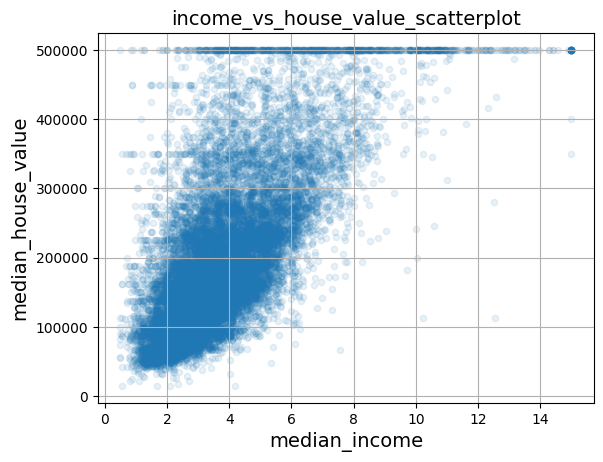

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
#save_fig("income_vs_house_value_scatterplot")  # extra code
plt.title("income_vs_house_value_scatterplot")
plt.show()



In [ ]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


TASK 4:

In [ ]:
# Create a new DataFrame, housing, which contains all the features (input data) except the target variable, median_house_value
strat_housing = strat_train_set.drop("median_house_value", axis=1)
# Create a new Series, housing_labels, which contains the target variable, median_house_value
strat_housing_labels = strat_train_set["median_house_value"].copy()
#The housing_labels Series now contains the target variable values, which will be used for training the machine learning model.
housing.info()



<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
 10  rooms_per_house     16512 non-null  float64
 11  bedrooms_ratio      16344 non-null  float64
 12  people_per_house    16512 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.8+ MB


In [ ]:
null_rows_idx = strat_housing.isnull().any(axis=1)
strat_housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [ ]:


# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option1 = strat_housing.copy()

# Remove rows where the total_bedrooms column has missing values (Option 1)
strat_housing_option1.dropna(subset=["total_bedrooms"], inplace=True)

# Attempt to display the first five rows that still contain missing values (if any)
strat_housing_option1.loc[null_rows_idx].head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [ ]:
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option2 = strat_housing.copy()

# Remove the total_bedrooms column entirely (Option 2)
strat_housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

# Attempt to display the first five rows that still contain missing values (if any)
strat_housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [ ]:
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option3 = strat_housing.copy()

# Calculate the median value of the total_bedrooms column in the housing DataFrame
median = strat_housing["total_bedrooms"].median()

# Fill the missing values in the total_bedrooms column of housing_option3 with the median value calculated in the previous step.
strat_housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3

strat_housing_option3.loc[null_rows_idx].head()

/tmp/ipykernel_3128/632447514.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  strat_housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


In [ ]:
# Import the SimpleImputer class from the sklearn.impute module
from sklearn.impute import SimpleImputer

# Create an imputer instance with the strategy to fill missing values with the median value
imputer = SimpleImputer(strategy="median")

In [ ]:
# Select only the numerical columns from the housing DataFrame and assign them to housing_num
strat_housing_num = strat_housing.select_dtypes(include=[np.number])

In [ ]:
# Fit the SimpleImputer instance to the numerical columns of the housing DataFrame
# This calculates the median values for each numerical column and stores them in the imputer
imputer.fit(strat_housing_num)

SimpleImputer(strategy='median')

In [ ]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
strat_housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
# Transform the numerical columns of the housing DataFrame using the fitted SimpleImputer
# This fills in missing values with the median values calculated during the fitting step
X = imputer.transform(strat_housing_num)

In [ ]:
# Retrieve the names of the features that the SimpleImputer was fitted on
# This provides a list of column names that were included in the imputation process
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [ ]:
# Convert the NumPy array resulting from the imputation back into a DataFrame
# Restore the original column names and row indices from the housing_num DataFrame
strat_housing_tr = pd.DataFrame(X, columns=strat_housing_num.columns,
                          index=strat_housing_num.index)

In [ ]:
strat_housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [ ]:
imputer.strategy

'median'

In [ ]:
from sklearn.ensemble import IsolationForest

# Create an instance of the IsolationForest with a fixed random state for reproducibility
isolation_forest = IsolationForest(random_state=42)

# Fit the IsolationForest model to the data and predict outliers
outlier_pred = isolation_forest.fit_predict(X)

In [ ]:
# The fit_predict method returns an array where 1 indicates an inlier and -1 indicates an outlier
outlier_pred

array([-1,  1,  1, ...,  1,  1,  1])

In [ ]:


# Extract the 'ocean_proximity' column from the housing DataFrame and assign it to housing_cat
strat_housing_cat = strat_housing[["ocean_proximity"]]

# Display the first 8 rows of the housing_cat DataFrame to preview the 'ocean_proximity' data
strat_housing_cat.head(8)



,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [ ]:
# Import the OrdinalEncoder from sklearn.preprocessing
from sklearn.preprocessing import OrdinalEncoder

# Create an instance of the OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Fit the OrdinalEncoder to the housing_cat data and transform it into numerical values
strat_housing_cat_encoded = ordinal_encoder.fit_transform(strat_housing_cat)

In [ ]:
strat_housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

TASK 5:

In [ ]:


# Import the MinMaxScaler from sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler

# Create an instance of the MinMaxScaler with the feature range set to [-1, 1]
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit the MinMaxScaler to the housing_num data and transform it
# This scales each numerical feature to the range [-1, 1]
strat_housing_num_min_max_scaled = min_max_scaler.fit_transform(strat_housing_num)



In [ ]:
# Import the StandardScaler from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
std_scaler = StandardScaler()

# Fit the StandardScaler to the housing_num data and transform it
# This standardizes each numerical feature by removing the mean and scaling to unit variance
strat_housing_num_std_scaled = std_scaler.fit_transform(strat_housing_num)



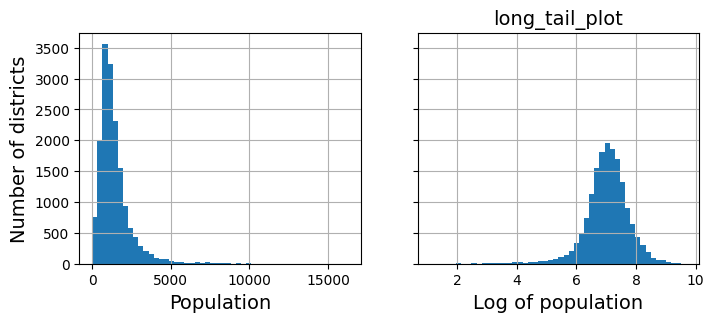

In [ ]:
# extra code – this cell generates Figure 2–17 in the Book
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
strat_housing["population"].hist(ax=axs[0], bins=50)
strat_housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
#save_fig("long_tail_plot")
plt.title("long_tail_plot")
plt.show()

In [ ]:

# Import the rbf_kernel function from sklearn.metrics.pairwise
from sklearn.metrics.pairwise import rbf_kernel

# Compute the RBF kernel similarity between the housing_median_age feature and the age 35
# The gamma parameter controls the influence of a single training example
age_simil_35 = rbf_kernel(strat_housing[["housing_median_age"]], [[35]], gamma=0.1)

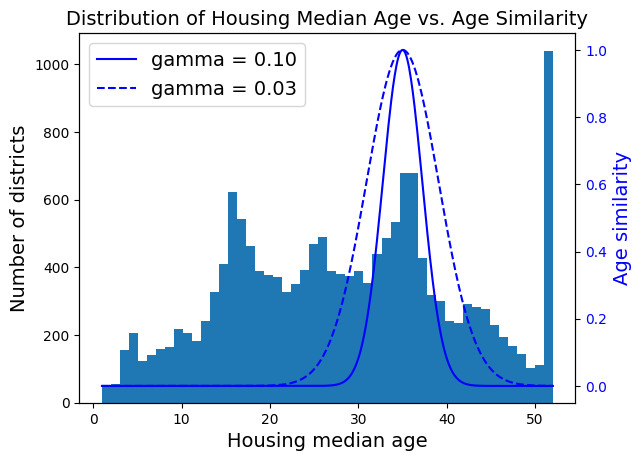

In [ ]:


# extra code – this cell generates Figure 2–18

ages = np.linspace(strat_housing["housing_median_age"].min(),
                   strat_housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(strat_housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
#save_fig("age_similarity_plot")
plt.title("Distribution of Housing Median Age vs. Age Similarity")
plt.show()



TASK 6:

In [ ]:

# Import the FunctionTransformer from sklearn.preprocessing
from sklearn.preprocessing import FunctionTransformer

# Create a FunctionTransformer for the logarithmic transformation
# np.log applies the natural logarithm, and np.exp is the inverse function
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

# Apply the logarithmic transformation to the population feature
log_pop = log_transformer.transform(strat_housing[["population"]])

In [ ]:


# Create a FunctionTransformer for the RBF kernel transformation
# rbf_kernel computes the RBF kernel similarity, with Y=[[35.]] and gamma=0.1 as additional arguments
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))

# Apply the RBF kernel transformation to the housing_median_age feature
age_simil_35 = rbf_transformer.transform(strat_housing[["housing_median_age"]])



In [ ]:
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

In [ ]:
# Define the coordinates of San Francisco (latitude, longitude)
sf_coords = 37.7749, -122.41

# Create a FunctionTransformer for the RBF kernel transformation
# rbf_kernel computes the RBF kernel similarity, with San Francisco's coordinates and gamma=0.1
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))


# Apply the RBF kernel transformation to the latitude and longitude features
# This computes the similarity of each housing unit's coordinates to San Francisco's coordinates
sf_simil = sf_transformer.transform(strat_housing[["latitude", "longitude"]])

In [ ]:
sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]])

In [ ]:
# Create a FunctionTransformer to calculate the ratio of the first column to the second column
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
# Apply the ratio transformer to a sample 2D NumPy array
# This computes the ratio for each row: first column value divided by second column value
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

# Define a custom transformer class for standard scaling
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # Initialize with an optional with_mean parameter
        self.with_mean = with_mean

    def fit(self, X, y=None): # Fit method to calculate mean and scale # y is required even though we don't use it
        X = check_array(X) # Validate input array # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0) # Calculate mean of each feature
        self.scale_ = X.std(axis=0) # Calculate standard deviation of each feature
        self.n_features_in_ = X.shape[1]  # Store the number of features # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X): # Transform method to standardize the data
        check_is_fitted(self)  # Ensure the transformer has been fitted
        X = check_array(X) # Validate input array
        assert self.n_features_in_ == X.shape[1] # Ensure the number of features matches
        if self.with_mean:
            X = X - self.mean_  # Center the data by subtracting the mean if with_mean is True
        return X / self.scale_ # Scale the data by dividing by the standard deviation

In [ ]:

# Import the KMeans class from sklearn.cluster
from sklearn.cluster import KMeans

# Define a custom transformer class for cluster similarity using K-means and RBF kernel
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        # Initialize with parameters for the number of clusters, RBF kernel gamma, and random state
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # Create and fit a K-means model with the specified number of clusters and random state
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        # Transform the data by computing the RBF kernel similarity to the cluster centers
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        # Generate feature names for the transformed data
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [ ]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(strat_housing[["latitude", "longitude"]],
                                           sample_weight=strat_housing_labels)

In [ ]:

similarities[:3].round(2)

array([[0.08, 0.  , 0.6 , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.14],
       [0.  , 0.99, 0.  , 0.04, 0.  , 0.  , 0.11, 0.  , 0.63, 0.  ],
       [0.44, 0.  , 0.3 , 0.  , 0.  , 0.7 , 0.  , 0.01, 0.  , 0.29]])

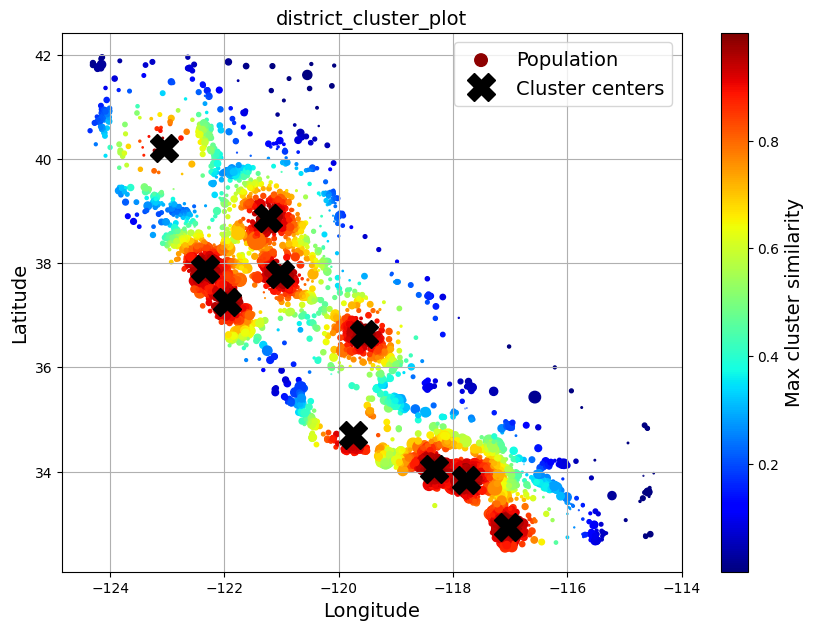

In [ ]:
# extra code – this cell generates Figure 2–19

strat_housing_renamed = strat_housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
strat_housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

strat_housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=strat_housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
#save_fig("district_cluster_plot")
plt.title("district_cluster_plot")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline

# Create a pipeline for preprocessing numerical attributes
# The pipeline includes two steps: imputation and standardization
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")), # Step 1: Impute missing values with the median
    ("standardize", StandardScaler()), # Step 2: Standardize features to have mean=0 and variance=1
])



In [ ]:
from sklearn.pipeline import make_pipeline

# Create a pipeline for preprocessing numerical attributes using make_pipeline
# The pipeline also includes two steps: imputation and standardization
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())



In [ ]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:

strat_housing_num_prepared = num_pipeline.fit_transform(strat_housing_num)
strat_housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [ ]:

df_housing_num_prepared = pd.DataFrame(
    strat_housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=strat_housing_num.index)

In [ ]:
df_housing_num_prepared.head(2)  # extra code to check the feature names

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


In [ ]:

num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [ ]:
num_pipeline[1]

StandardScaler()

In [ ]:
num_pipeline[:-1]

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median'))])

In [ ]:
num_pipeline.named_steps["simpleimputer"]

SimpleImputer(strategy='median')

In [ ]:
num_pipeline.set_params(simpleimputer__strategy="median")

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:
# Import the ColumnTransformer class from sklearn.compose
from sklearn.compose import ColumnTransformer

# Define the numerical attributes
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]

# Define the categorical attributes
cat_attribs = ["ocean_proximity"]

# Create a pipeline for preprocessing categorical attributes
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # Step 1: Impute missing values with the most frequent value
    OneHotEncoder(handle_unknown="ignore"))  # Step 2: One-hot encode categorical features and ignore unknown categories

# Combine numerical and categorical pipelines using ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs), # Apply the numerical pipeline to numerical attributes
    ("cat", cat_pipeline, cat_attribs),  # Apply the categorical pipeline to categorical attributes
])

In [ ]:
from sklearn.compose import make_column_selector, make_column_transformer

In [ ]:
strat_housing_prepared = preprocessing.fit_transform(strat_housing)

In [ ]:
# extra code – shows that we can get a DataFrame out if we want
strat_housing_prepared_fr = pd.DataFrame(
    strat_housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=strat_housing.index)
strat_housing_prepared_fr.head(2)



,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0


In [ ]:
print(strat_housing_prepared.shape)

(16512, 13)
